In [2]:
import os 
from pathlib import Path 
import csv

In [3]:
data_folder = "/home/lehoangvu/Project_AIDE1/data/CUB_200_2011"

In [4]:
train_test_split_file = os.path.join(data_folder, "train_test_split.txt")
image_folder = os.path.join(data_folder, "images")
images_file = os.path.join(data_folder, "images.txt")
bounding_boxes_file = os.path.join(data_folder, "bounding_boxes.txt")

In [5]:
csv_rows = []

with open(images_file, 'r') as images_f, \
    open(train_test_split_file, 'r') as split_f, \
    open(bounding_boxes_file, 'r') as bbox_f:
        
        image_filenames = images_f.readlines()
        split_lines = split_f.readlines()
        bbox_lines = bbox_f.readlines()

In [15]:
image_filenames[2888]

'2889 050.Eared_Grebe/Eared_Grebe_0025_34344.jpg\n'

In [16]:
# get 50 first classes

stop_line = 2889

for img_line, split_line, bbox_line in zip(image_filenames[:stop_line], split_lines[:stop_line], bbox_lines[:stop_line]):
    img_id, img_path = img_line.strip().split()
    _, is_train = split_line.strip().split()
    _, x, y, w, h = bbox_line.strip().split()
    
    csv_rows.append({
        'image_id': img_id,
        'image_path': os.path.join(image_folder, img_path),
        'is_train': int(is_train),
        'bbox_x': float(x),
        'bbox_y': float(y),
        'bbox_w': float(w),
        'bbox_h': float(h)
    })
    
with open('image_data.csv', 'w', newline='') as csvfile:
    fieldnames = ['image_id', 'image_path', 'is_train', 'bbox_x', 'bbox_y', 'bbox_w', 'bbox_h']
    writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
    
    writer.writeheader()
    for row in csv_rows:
        writer.writerow(row)

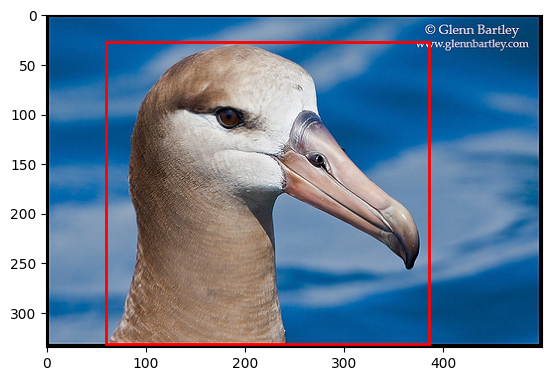

In [18]:
import matplotlib.pyplot as plt
example_row = csv_rows[0]
image = plt.imread(example_row['image_path'])
x, y, w, h = example_row['bbox_x'], example_row['bbox_y'], example_row['bbox_w'], example_row['bbox_h']
fig, ax = plt.subplots(1)
ax.imshow(image)
rect = plt.Rectangle((x, y), w, h, linewidth=2, edgecolor='r', facecolor='none')
ax.add_patch(rect)
plt.show()